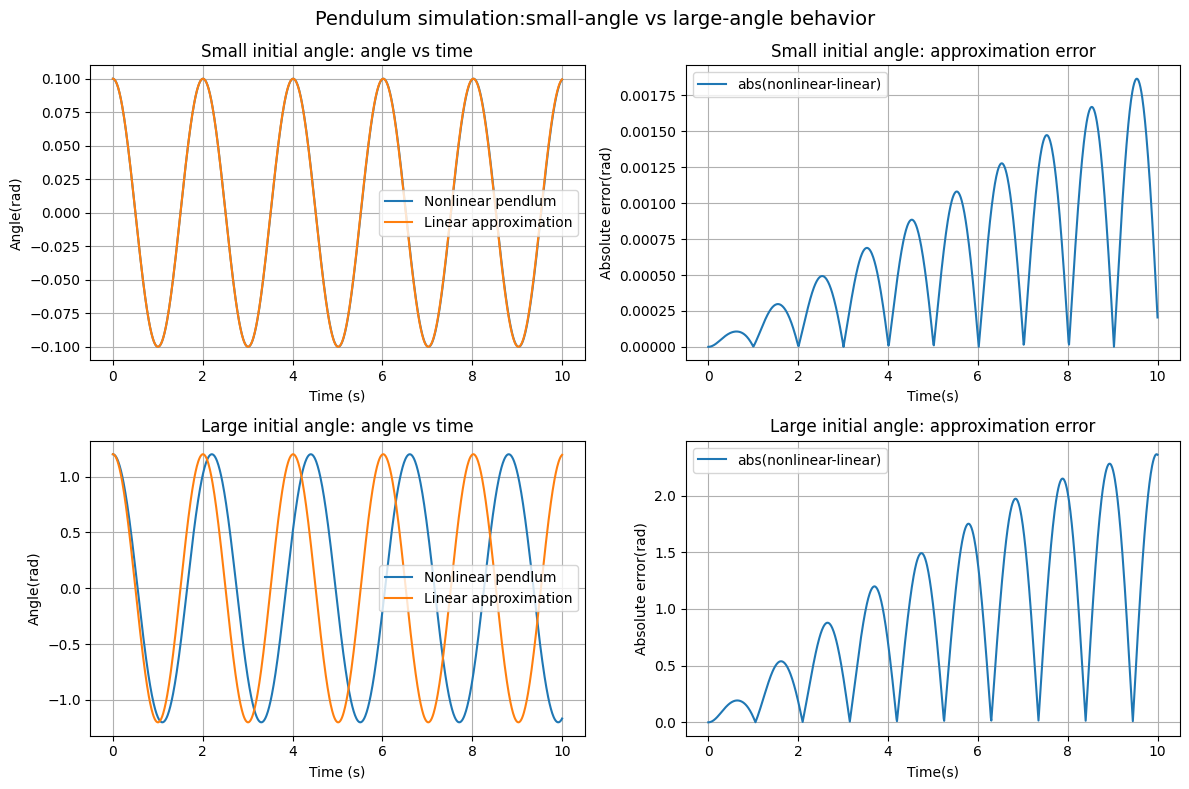

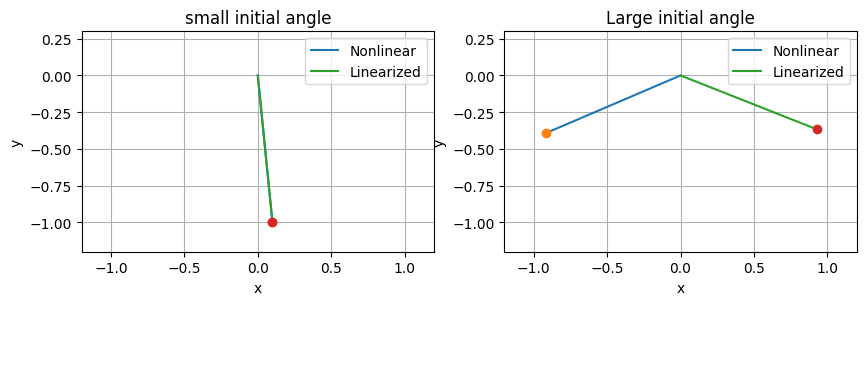

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation , PillowWriter

#------------------------------
# Physical paramters
#------------------------------
g = 9.81  # gravity (m/s^2)
L = 1.0     # length of the pendulum (m)
T_end = 10.0 # total simulation time (s)
dt = 0.01    # time step (s)
t = np.arange(0, T_end + dt , dt) 

#------------------------------
# RK4 solver for the pendulum
# theta' = omega
# omega' = - (g/L) * sin(theta)    nonlinear 
# omega' = - (g/L) * theta          linearized
#------------------------------
def rk4_pendulum(theta0, omega0, t, linear = False):
    dt = t[1] - t[0]
    y = np.zeros((len(t), 2))  # columns: [theta, omega]
    y[0] = [theta0, omega0]

    def f(state):
        theta, omega = state
        if linear:
            return np.array([omega, - (g/L) * theta])
        else:
            return np.array([omega, - (g/L) * np.sin(theta)])
        
    for n in range(len(t) - 1):
        k1 = f(y[n])
        k2 = f(y[n] + 0.5 * dt * k1)
        k3 = f(y[n] + 0.5 * dt * k2)
        k4 = f(y[n] + dt * k3)
        y[n+1] = y[n] + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return y[:, 0], y[:, 1]  # return theta and omega

#------------------------------
# Two cases:
# small theta and large theta
#------------------------------
cases = {
    "Small initial angle": 0.10, 
    "Large initial angle": 1.20
}
omega0 = 0.0

results = {}
for label, theta0 in cases.items():
    theta_n1, omega_n1 = rk4_pendulum(theta0, omega0, t, linear= False)
    theta_lin, omega_lin = rk4_pendulum(theta0, omega0, t, linear = True)

    results[label] = {
        "theta0": theta0,
        "theta_n1":theta_n1,
        "omega_n1":omega_n1,
        "theta_lin":theta_lin,
        "omega_lin":omega_lin,
        "error":np.abs(theta_n1 - theta_lin)
    }


#------------------------------
# static comparison figure
#-------------------------------
fig, axes = plt.subplots(2 ,2 ,figsize=(12, 8))

for row, (label, data) in enumerate(results.items()):
    ax1 = axes[row, 0]
    ax2 = axes[row, 1]

    ax1.plot(t, data["theta_n1"], label="Nonlinear pendlum")
    ax1.plot(t, data["theta_lin"], label="Linear approximation")
    ax1.set_title(f"{label}: angle vs time")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Angle(rad)")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(t, data["error"], label="abs(nonlinear-linear)")
    ax2.set_title(f"{label}: approximation error")
    ax2.set_xlabel("Time(s)")
    ax2.set_ylabel("Absolute error(rad)")
    ax2.legend()
    ax2.grid(True)

fig.suptitle("Pendulum simulation:small-angle vs large-angle behavior",
             fontsize=14)
fig.tight_layout()
plt.savefig("pendulum_small_vs_large_comarison.png", dpi=180,
            bbox_inches= "tight")
plt.show()

#----------------------------------
#Convert angle to coordinates
#-----------------------------------
def coords(theta):
    x = L * np.sin(theta)
    y = -L * np.cos(theta)
    return x , y

small = results["Small initial angle"]
large = results["Large initial angle"]

x_small_n1, y_small_n1 = coords(small["theta_n1"])
x_small_lin, y_small_lin = coords(small["theta_lin"])
x_large_n1, y_large_n1 = coords(large["theta_n1"])
x_large_lin, y_large_lin = coords(large["theta_lin"])


#----------------------------
#Animation
#Left panel: small theta
#Right panel: large theta
#------------------------------
fig, axes = plt.subplots(1,2,figsize=(10,5))

for ax, title in zip(axes, ["small initial angle", "Large initial angle"]):
    ax.set_xlim(-1.2*L, 1.2*L)
    ax.set_ylim(-1.2*L, 0.3*L)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)


#Small angle panel
line_small_n1 , = axes[0].plot([], [], label= "Nonlinear")
bob_small_n1 , = axes[0].plot([], [], marker="o")
line_small_lin, = axes[0].plot([], [], label="Linearized")
bob_small_lin, = axes[0].plot([], [], marker="o")
axes[0].legend()

#Large angle panel
line_large_n1, = axes[1].plot([], [], label="Nonlinear")
bob_large_n1, = axes[1].plot([], [], marker="o")
line_large_lin, = axes[1].plot([], [], label="Linearized")
bob_large_lin, = axes[1].plot([], [], marker="o")
axes[1].legend()

time_text = fig.text(0.5, 0.02, "", ha="center")

step = 5
frames = range(0,len(t), step)

def init():
    return [line_small_n1, bob_small_n1, line_small_lin, bob_small_lin,
            line_large_n1, bob_large_n1, line_large_lin, bob_large_lin,
            time_text
    ]

def update(i):
    #small angle
    line_small_n1.set_data([0, x_small_n1[i]],[0, y_small_n1[i]])
    bob_small_n1.set_data([x_small_n1[i]],[y_small_n1[i]])
    line_small_lin.set_data([0, x_small_lin[i]],[0,y_small_lin[i]])
    bob_small_lin.set_data([x_small_lin[i]],[y_small_lin[i]])

    #large angle
    line_large_n1.set_data([0, x_large_n1[i]],[0, y_large_n1[i]])
    bob_large_n1.set_data([x_large_n1[i]],[y_large_n1[i]])
    line_large_lin.set_data([0, x_large_lin[i]],[0, y_large_lin[i]])
    bob_large_lin.set_data([x_large_lin[i]], [y_large_lin[i]])


    time_text.set_text(f"t= {t[i]:.2f} s")
    return [
        line_small_n1, bob_small_n1, line_small_lin, bob_small_lin,
        line_large_n1, bob_large_n1, line_large_lin, bob_large_lin,
        time_text
    ]


anim = FuncAnimation(fig, update, frames= frames, init_func=init, blit=True)
anim.save("pendulum_simulation_comparison.gif", writer=PillowWriter(fps=20))
plt.show()




